# Polynomial Regression

Polynomial Regression is a form of linear regression in which the relationship between the independent variable $x$ and the dependent variable $y$ is modeled as an $n$-th degree polynomial. Although it fits a non-linear model to the data, as a statistical estimation problem it is linear, in the sense that the regression function is linear in the unknown parameters that are estimated from the data.

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.datasets import fetch_california_housing

## 1. A Simple 1D Example: Visualizing Polynomial Fits

Let's create some synthetic non-linear data to see how polynomial regression works in 1D. We will try fitting models of different degrees to understand **underfitting**, **good fit**, and **overfitting**.

In [49]:
# Generate synthetic data
np.random.seed(42)
X_syn = np.sort(np.random.rand(40, 1) * 10) # [0, 10)
y_syn = np.sin(X_syn).ravel() + np.random.randn(40) * 0.5

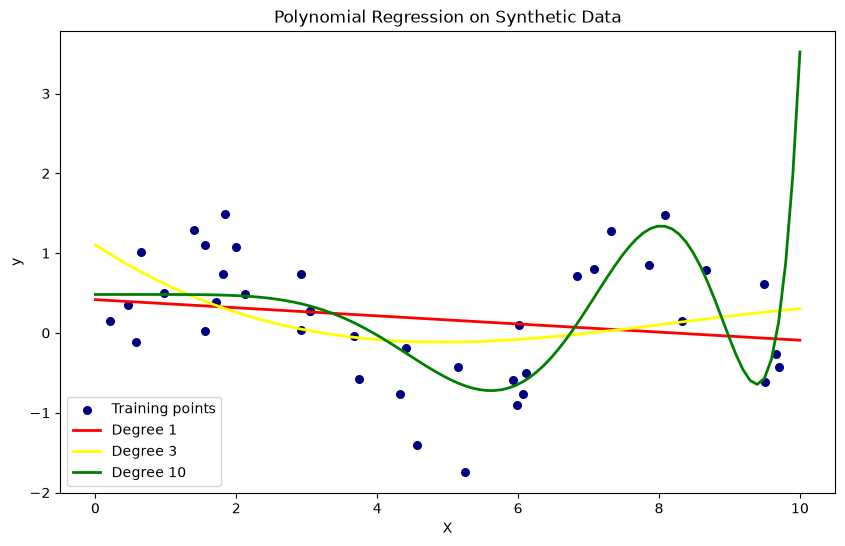

In [50]:
plt.figure(figsize=(10, 6))
plt.scatter(X_syn, y_syn, color='navy', s=30, marker='o', label="Training points")

X_test_syn = np.linspace(0, 10, 100)[:, np.newaxis]

degrees = [1, 3, 10]
colors = ['red', 'yellow', 'green']

for idx, degree in enumerate(degrees):
    # Using make_pipeline to chain degree extraction and linear regression
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_syn, y_syn)
    y_plot = model.predict(X_test_syn)
    
    plt.plot(X_test_syn, y_plot, color=colors[idx], linewidth=2, label="Degree %d" % degree)

plt.legend(loc='lower left')
plt.title("Polynomial Regression on Synthetic Data")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### Observations:
- **Degree 1 (Linear)**: Underfits the data. It cannot capture the curve of the sine wave.
- **Degree 3**: Captures the underlying pattern quite well without following the noise.
- **Degree 10**: Memorizes the training points (overfitting) and oscillates wildly between them. It will perform poorly on unseen data.

## 2. California Housing

We will use the California Housing dataset to predict house prices based on features like median income, average rooms, etc. The original script showed performance dropping as degrees increased, let's explore why.

In [51]:
data = fetch_california_housing()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Number of original features: {X.shape[1]}")
print(f"Dataset size: {X.shape[0]} samples")

Number of original features: 8
Dataset size: 20640 samples


Let's see what happens when we increase the degree of polynomial features on this multi-dimensional dataset.

In [62]:
for degree in range(1, 5):
    model = make_pipeline(
        PolynomialFeatures(degree=degree, interaction_only=False, include_bias=True),
        LinearRegression()
    )
    model.fit(X_train, y_train)
    poly = model.named_steps["polynomialfeatures"]
    lr = model.named_steps["linearregression"]

    # print("Features:")
    # print(poly.get_feature_names_out())

    # print("\nWeights:")
    # print(lr.coef_)

    # print("\nIntercept:")
    # print(lr.intercept_)
    y_pred = model.predict(X_test)
    
    # Calculate how many features the Polynomial expansion resulted in.
    num_features = model.steps[0][1].n_output_features_

    print(f"--- Polynomial degree: {degree} ---")
    print(f"Number of expanded features: {num_features}")
    print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
    if r2_score(y_test, y_pred) < -1:
        print(f"R²:  {r2_score(y_test, y_pred):.2e} (Massive Overfitting!)")
    else:
        print(f"R²:  {r2_score(y_test, y_pred):.4f}")
    print()

--- Polynomial degree: 1 ---
Number of expanded features: 9
MSE: 0.5559
R²:  0.5758

--- Polynomial degree: 2 ---
Number of expanded features: 45
MSE: 0.6045
R²:  0.5387

--- Polynomial degree: 3 ---
Number of expanded features: 165
MSE: 1.2687
R²:  0.0318

--- Polynomial degree: 4 ---
Number of expanded features: 495
MSE: 1.3059
R²:  0.0034



In [63]:
print(model.steps[0][1].n_output_features_)

495


### The Curse of Dimensionality & Overfitting
As you can see, when moving from degree 1 to degree 2, the features expand from 9 to 45. The model's performance on the test set is sometimes worse because of numerical instability and overfitting.

**Why does this happen?**
1. **Feature Explosion**: An 8-feature dataset expanded to degree 4 polynomials yields nearly 495 features.
2. **Collinearity**: These polynomial features are highly correlated (e.g., $x_1$ and $x_1^2$ and $x_1^3$), which leads to huge regression coefficients and an unstable linear model that fails spectacularly on test data.
3. **Scale variations**: Real-world features differ wildly in scale. Raising them to powers exacerbates these differences, causing numerical overflow or instability.

### How to Fix It?
To make high degree polynomials work or at least remain stable, we must:
1. **Scale the data** (e.g. `StandardScaler`).
2. **Use Regularization** (e.g. `Ridge` or `Lasso`) instead of vanilla `LinearRegression` to keep coefficients small.

In [64]:
print("Testing Degree 3 with Scaling and Ridge Regularization (L2):\n")

model_regularized = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=3, include_bias=False),
    Ridge(alpha=10.0) # Penalty term
)

model_regularized.fit(X_train, y_train)
y_pred_reg = model_regularized.predict(X_test)

print(f"Number of expanded features: {model_regularized.steps[1][1].n_output_features_}")
print(f"MSE: {mean_squared_error(y_test, y_pred_reg):.4f}")
print(f"R²:  {r2_score(y_test, y_pred_reg):.4f}")

Testing Degree 3 with Scaling and Ridge Regularization (L2):

Number of expanded features: 164
MSE: 19.8281
R²:  -14.1312


x=min(feature,degree)
summation (x,k)
k=0

## 3. Regularization: Ridge and Lasso Regression

When we saw our high-degree polynomial models fail earlier, we touched briefly on regularization. Let's dive deeper into Ridge and Lasso regression, how they work mathematically, and when to use them.

### What is Regularization?
Regularization is a technique used to prevent overfitting by adding a penalty term to the loss function. In standard Linear Regression, we minimize the Residual Sum of Squares (RSS):

$$ \text{Loss} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

When models become too complex (like in high-degree polynomials), the coefficients (weights) can become extremely large in magnitude as they attempt to fit the noise in the data. Regularization constrains these coefficients by penalizing overly large values.

### 3.1 Ridge Regression (L2 Regularization)

Ridge Regression adds an $L_2$ penalty term to the loss function. It shrinks the coefficients toward zero, but they rarely become exactly zero.

**Mathematical Formulation:**
$$ \text{Loss}_{Ridge} = \text{RSS} + \alpha \sum_{j=1}^{p} w_j^2 $$
Where:
- $\alpha$ (or $\lambda$) is the tuning parameter that controls the strength of the penalty. If $\alpha = 0$, it reverts to standard Linear Regression.
- $w_j^2$ is the squared magnitude of the coefficients.

**Why does it work?**
By penalizing the squared weights, Ridge ensures that no single feature strictly dominates the prediction. It handles collinearity (highly correlated features) very well, which is an extremely common issue when we independently create vast arrays of polynomial features.

In [65]:
from sklearn.linear_model import Lasso
import pandas as pd

degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Crucial: Always scale before applying regularization so that penalties apply uniformly!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# Fit Ridge
ridge = Ridge(alpha=100.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)


### 3.2 Lasso Regression (L1 Regularization)

Lasso (Least Absolute Shrinkage and Selection Operator) applies an $L_1$ penalty term.

**Mathematical Formulation:**
$$ \text{Loss}_{Lasso} = \text{RSS} + \alpha \sum_{j=1}^{p} |w_j| $$
Where $|w_j|$ is the absolute value of the coefficients.

**Why does it work and how is it different?**
Unlike $L_2$, the $L_1$ penalty has a geometric property that forces some coefficients to become **exactly zero**. This acts as an automatic **feature selection** mechanism. In a dataset expanded to hundreds of polynomial features, Lasso will identify and discard the unimportant/redundant ones, leaving us with a much sparser and often more interpretable model.

In [66]:
# Fit Lasso
# We increase max_iter because Lasso coordinate descent can take longer to converge on complex overlapping datasets
lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)


### 3.3 Comparing the Models: Shrinkage vs Feature Selection

Let's look at their test performance and analyze the resulting coefficients. Notice how Lasso forces many coefficients exactly to 0, completely discarding irrelevant combinations generated by polynomial mapping!

--- Performance Comparison ---
Ridge MSE: 0.9647 | R²: 0.2638
Lasso MSE: 0.5840 | R²: 0.5543

--- Coefficient Sparsity ---
Total Features: 164
Ridge non-zero coefficients: 164 (Keeps almost all features)
Lasso non-zero coefficients: 21 (Zeroed out 143 features)



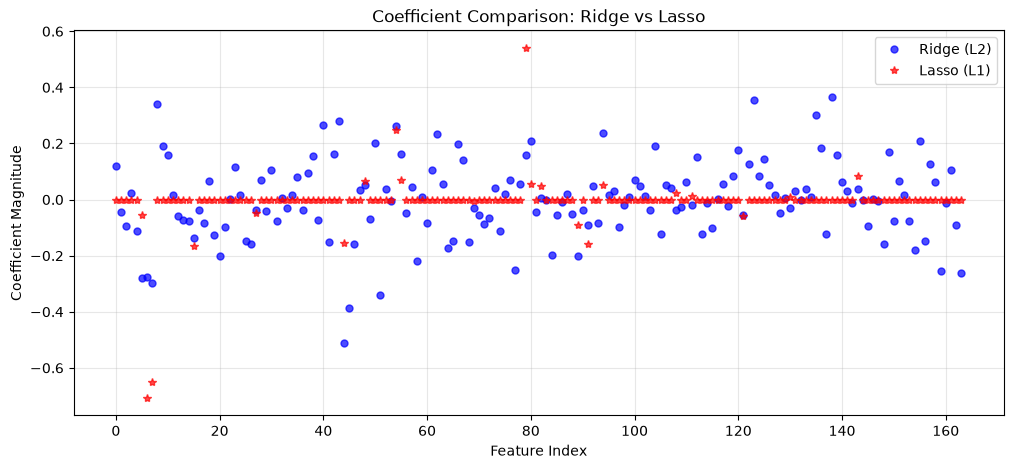

In [67]:
# Evaluate Performance
print("--- Performance Comparison ---")
print(f"Ridge MSE: {mean_squared_error(y_test, y_pred_ridge):.4f} | R²: {r2_score(y_test, y_pred_ridge):.4f}")
print(f"Lasso MSE: {mean_squared_error(y_test, y_pred_lasso):.4f} | R²: {r2_score(y_test, y_pred_lasso):.4f}\n")

# Analyze Coefficients
ridge_coefs = ridge.coef_
lasso_coefs = lasso.coef_

non_zero_ridge = np.sum(np.abs(ridge_coefs) > 0)
non_zero_lasso = np.sum(np.abs(lasso_coefs) > 0)
total_features = len(ridge_coefs)

print("--- Coefficient Sparsity ---")
print(f"Total Features: {total_features}")
print(f"Ridge non-zero coefficients: {non_zero_ridge} (Keeps almost all features)")
print(f"Lasso non-zero coefficients: {non_zero_lasso} (Zeroed out {total_features - non_zero_lasso} features)\n")

# Visualizing the coefficients
plt.figure(figsize=(12, 5))
plt.plot(ridge_coefs, alpha=0.7, linestyle='none', marker='o', markersize=5, color='blue', label='Ridge (L2)', zorder=2)
plt.plot(lasso_coefs, alpha=0.7, linestyle='none', marker='*', markersize=6, color='red', label='Lasso (L1)', zorder=3)
plt.title("Coefficient Comparison: Ridge vs Lasso")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Magnitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()